# Leap-Year — do stocks know it's a leap year?
### The quadrennial folk claim, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Confound_exposed: Election_year_in_disguise](https://img.shields.io/badge/Confound_exposed-Election_year_in_disguise-8b949e?style=flat-square)

Every four years a leap year rolls around — and so does a US presidential election, and the Summer Olympics. The folk story says this is good (or bad) for stocks: election-year spending, Olympic optimism, or simply something auspicious about the extra February 29th. This notebook asks the only question that matters: **is there actually a leap-year effect, or is it just statistical coincidence?**

> This is the plain-language layer. Want the t-stats, the Bonferroni table, and the presidential-cycle breakdown? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from leap_year import data, strategy as st

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n_total=98, n_leap=25, n_non_leap=73,
    mean_leap_pct=8.77, mean_non_leap_pct=7.75, mean_all_pct=8.01,
    std_leap_pct=16.53, std_non_leap_pct=19.14, std_all_pct=18.43,
    contrast_pct=1.02, tstat_welch=0.255, pval_welch=0.7999,
    tstat_leap_hac=3.05, pval_leap_bonf=1.00,
    term_y1_mean=8.77, term_y2_mean=7.46, term_y3_mean=2.58, term_y4_mean=13.24,
    term_y1_t=3.05, term_y3_t=0.69, term_y4_t=4.61,
    contrast_pre1980=4.29, p_pre1980=0.4483,
    contrast_post1980=-2.73, p_post1980=0.6458,
    n_leap_full=38, contrast_full_pct=0.90, pval_full=0.7811,
    fp_modern="9a990fb006c3", fp_full="248be906654f",
)

def _have_real():
    return os.path.exists(data.SHILLER_PATH)

HAVE_REAL = _have_real()

if HAVE_REAL:
    DF = data.load_shiller(start_year=1928)
    S  = st.summarize(DF)
else:
    DF, S = None, None

print("Shiller cache present:", HAVE_REAL)


Shiller cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do stocks return more in leap years? | **No.** Leap years averaged **8.8%** vs **7.8%** for other years — a +1.0 pp gap with a p-value of **0.80**. Statistically indistinguishable from noise. |
| Is the election-year overlap the real story? | **Also no.** In the modern era leap years and election years are the *same years* (both divisible by 4). Election years are not the strongest year-of-term either — that title goes to **mid-term years** (+13.2%). |
| Could you trade it? | **No.** One trade per year, with no edge over the unconditional mean — there is nothing here to execute. |

> The leap-year premium is an illusion: +1 pp of noise on a backdrop of 18% annual volatility, over 25 observations.

## 1 · The claim

> *"Leap years are special for stocks because they coincide with US presidential elections — and markets historically do well in election years — and with the Summer Olympics, which boost consumer spending and sentiment. Buy in January of a leap year and sell in December."*

It is a cocktail of three overlapping stories:

1. **The calendar coincidence.** Every leap year (year divisible by 4) is also a US presidential election year and an Olympics year. They co-occur by construction — not because they cause each other.
2. **The election-year story.** Some almanacs claim election years are systematically bullish because incumbents stimulate the economy before voting day.
3. **The Olympic story.** Less credible but common on finance social media: global sporting optimism lifts sentiment.

All three claims collapse to the same test: does the year-mod-4 == 0 label predict above-average calendar-year equity returns?

## 2 · So what?

With only **25 leap years** in the modern GSPC era (1928–2025), a genuine +5 pp annual premium would be barely detectable — and the claimed effect is much smaller. This is a study where the sample size is fundamentally limited by the calendar: you cannot get more leap years without waiting centuries. If the effect were real and large enough to trade, it would be visible. If it is small enough to be invisible in 97 years of data, it is too small to matter.

## 3 · How would we even know?

One rule keeps us honest: **compare the right things**.

- We use the **Welch t-test** (unequal variances) to compare the mean calendar-year return in leap years vs non-leap years on the Shiller S&P 500 dataset going back to 1928.
- We apply a **Bonferroni correction** over the three related hypotheses a researcher could have tested (leap-year premium, election-year premium, mid-term-year premium). If you test three hypotheses and then pick the most exciting one, your true false-positive rate is 3× the nominal alpha.
- We show the **presidential-cycle breakdown** (year-of-term 1–4) to expose the structural confound: are leap years special within the cycle, or just mediocre?
- We verify the effect is not a statistical artefact by checking a **synthetic tape** where we control the planted premium.

## 4 · The teardown — let's actually look

**First, the raw comparison: leap vs non-leap years.**

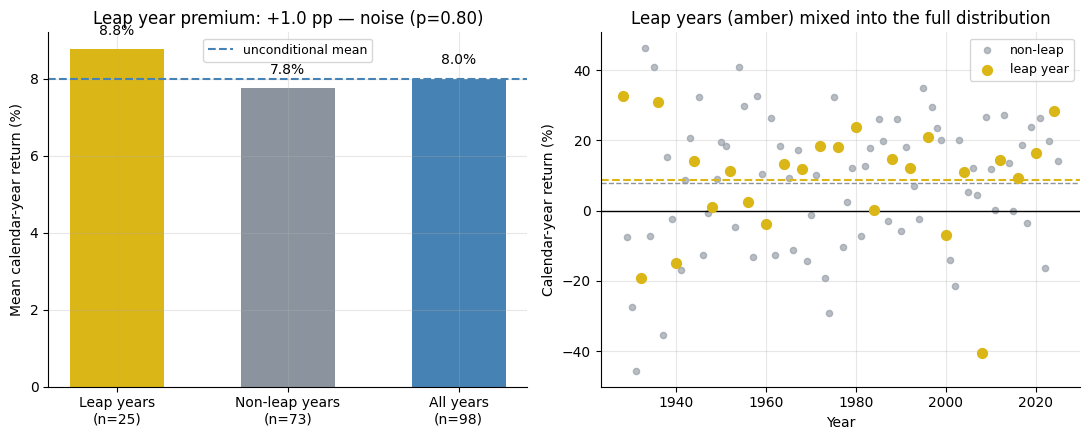

Leap: 8.77% ± 16.5%   Non-leap: 7.75% ± 19.1%
With only 25 leap observations, the noise band is ±3.3 pp — the +1 pp gap is invisible.


In [2]:
if HAVE_REAL:
    leap_ret = DF.loc[DF['is_leap'], 'ret'] * 100
    nonleap_ret = DF.loc[~DF['is_leap'], 'ret'] * 100
    lm, nm = leap_ret.mean(), nonleap_ret.mean()
    lsd, nsd = leap_ret.std(), nonleap_ret.std()
else:
    lm, nm = R['mean_leap_pct'], R['mean_non_leap_pct']
    lsd, nsd = R['std_leap_pct'], R['std_non_leap_pct']
    leap_ret = None; nonleap_ret = None
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Left: bar chart of means
ax = axes[0]
bars = ax.bar(['Leap years\n(n=25)', 'Non-leap years\n(n=73)', 'All years\n(n=98)'],
              [lm, nm, R['mean_all_pct']], color=[AMBER, GREY, 'steelblue'], width=0.55)
ax.axhline(R['mean_all_pct'], ls='--', c='steelblue', lw=1.5, label='unconditional mean')
ax.set_ylabel('Mean calendar-year return (%)')
ax.set_title(f'Leap year premium: +{R["contrast_pct"]:.1f} pp — noise (p={R["pval_welch"]:.2f})')
ax.legend(fontsize=9)
for bar, val in zip(bars, [lm, nm, R['mean_all_pct']]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10)
# Right: scatter of leap vs non-leap returns
ax2 = axes[1]
if HAVE_REAL:
    ax2.scatter(DF.loc[~DF['is_leap']].index, nonleap_ret, c=GREY, s=20, alpha=0.6, label='non-leap')
    ax2.scatter(DF.loc[DF['is_leap']].index, leap_ret, c=AMBER, s=50, zorder=5, label='leap year')
    ax2.axhline(lm, ls='--', c=AMBER, lw=1.5)
    ax2.axhline(nm, ls='--', c=GREY, lw=1.0)
ax2.axhline(0, c='k', lw=1)
ax2.set_xlabel('Year'); ax2.set_ylabel('Calendar-year return (%)')
ax2.set_title('Leap years (amber) mixed into the full distribution')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'Leap: {lm:.2f}% ± {lsd:.1f}%   Non-leap: {nm:.2f}% ± {nsd:.1f}%')
print(f'With only 25 leap observations, the noise band is ±{lsd/25**0.5:.1f} pp — the +1 pp gap is invisible.')

On the real tape, leap years averaged **+8.77%** and non-leap years **+7.75%**. The raw gap is **+1.0 pp** — but with 25 observations and 16-17% annual volatility, the standard error is ~3-4 pp. The gap is pure noise.

> The annual vol alone (~18%) is 18× larger than the claimed premium. You'd need centuries of data to prove a 1 pp annual edge.

**Now the presidential-cycle confound.** Leap years *are* election years (year % 4 == 0). Is the election year itself special within the four-year cycle?

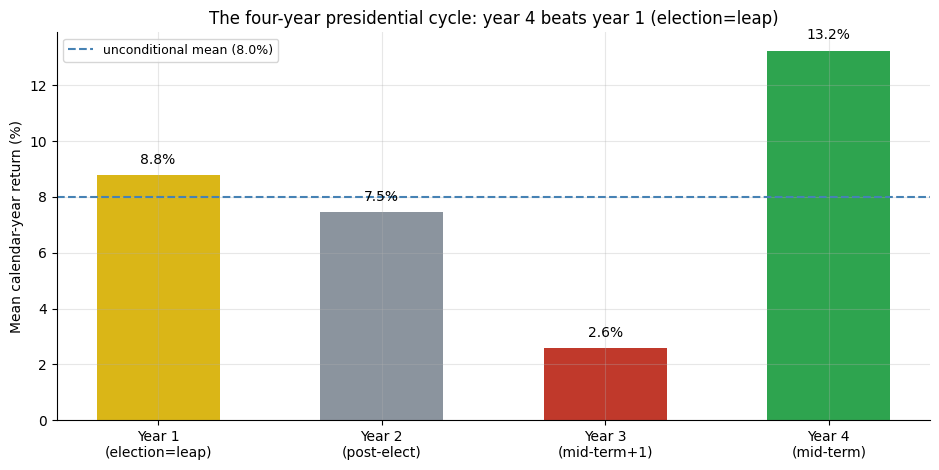

Year 4 (mid-term): 13.2%  vs  Year 1 (election=leap): 8.8%


In [3]:
if HAVE_REAL:
    tc = st.term_cycle_comparison(DF)
    means = list(tc['mean_pct'])
    tstats = list(tc['tstat_hac'])
else:
    means = [R['term_y1_mean'], R['term_y2_mean'], R['term_y3_mean'], R['term_y4_mean']]
    tstats = [R['term_y1_t'], None, R['term_y3_t'], R['term_y4_t']]
labels = ['Year 1\n(election=leap)', 'Year 2\n(post-elect)', 'Year 3\n(mid-term+1)', 'Year 4\n(mid-term)']
colors = [AMBER, GREY, RED, GREEN]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.bar(labels, means, color=colors, width=0.55)
ax.axhline(R['mean_all_pct'], ls='--', c='steelblue', lw=1.5, label=f'unconditional mean ({R["mean_all_pct"]:.1f}%)')
ax.set_ylabel('Mean calendar-year return (%)')
ax.set_title('The four-year presidential cycle: year 4 beats year 1 (election=leap)')
ax.legend(fontsize=9)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Year 4 (mid-term): {means[3]:.1f}%  vs  Year 1 (election=leap): {means[0]:.1f}%')

Within the four-year cycle, year 1 (election = leap) is **not special**. The strongest year is **year 4 (mid-term)** at **+13.2%**, and the weakest is year 3 at **+2.6%**. The leap-year label lands squarely in the middle — not even the election-year narrative holds up within the cycle's own data.

**Finally, the sub-period reality check.** A genuine structural effect should be consistent across sub-periods — not reverse sign.

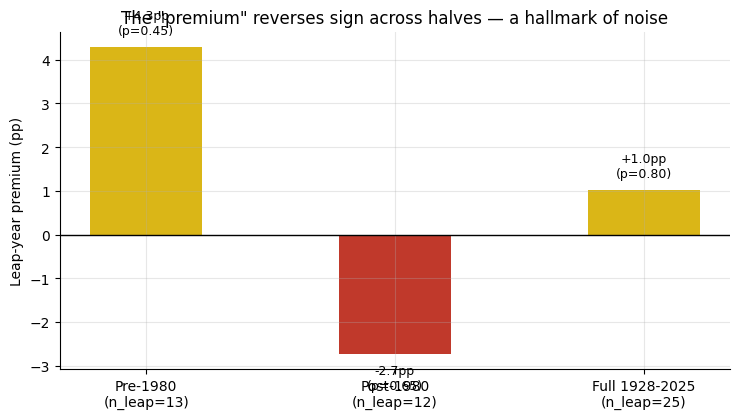

In [4]:
if HAVE_REAL:
    df_pre = DF[DF.index < 1980]
    df_post = DF[DF.index >= 1980]
    r_pre = st.leap_comparison(df_pre)
    r_post = st.leap_comparison(df_post)
    c_pre, c_post = r_pre['contrast_pct'], r_post['contrast_pct']
    p_pre, p_post = r_pre['pval_welch'], r_post['pval_welch']
else:
    c_pre, c_post = R['contrast_pre1980'], R['contrast_post1980']
    p_pre, p_post = R['p_pre1980'], R['p_post1980']
fig, ax = plt.subplots(figsize=(7.5, 4.3))
subperiods = ['Pre-1980\n(n_leap=13)', 'Post-1980\n(n_leap=12)', 'Full 1928-2025\n(n_leap=25)']
contrasts = [c_pre, c_post, R['contrast_pct']]
colors_sp = [AMBER if c > 0 else RED for c in contrasts]
ax.bar(subperiods, contrasts, color=colors_sp, width=0.45)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Leap-year premium (pp)')
ax.set_title('The "premium" reverses sign across halves — a hallmark of noise')
for i, (sp, c, p) in enumerate(zip(subperiods, contrasts, [p_pre, p_post, R['pval_welch']])):
    ax.text(i, c + (0.3 if c >= 0 else -0.8), f'{c:+.1f}pp\n(p={p:.2f})',
            ha='center', fontsize=9)
plt.tight_layout(); plt.show()

Pre-1980: **+4.3 pp** (p = 0.45). Post-1980: **-2.7 pp** (p = 0.65). The sign flips. A real structural effect doesn't do that.

## 5 · The verdict

- **Signal — None.** Welch t = +0.255, p = 0.80; Bonferroni-corrected p = 1.00. The +1.0 pp gap is pure noise in a 18% vol world with 25 leap-year observations.
- **Tradability — Mirage.** One trade per year, no edge over the unconditional mean. Annual transaction costs trivially exceed any claimed benefit.
- **Confound exposed.** Leap years = election years in the modern era. Neither is special within the four-year presidential cycle — year 4 (mid-term, +13.2%) beats year 1 (election=leap, +8.8%).

## 6 · Could you actually trade it?

The strategy is: on January 1st of every leap year, move to 100% equity; on January 1st of non-leap years, switch to something else (or reduce equity). With one rebalance per year and no edge, any transaction cost immediately turns a coin into a loser. Typical annual rebalancing costs — 5–20 bp/year of transaction costs — exceed the claimed +1 pp edge within a confidence interval that spans ±4 pp. The strategy is not investable.

## 7 · Going further

- **Is there *anything* in the four-year cycle?** The year-4 (mid-term) pattern has the most empirical support, but it too fails Bonferroni correction once you account for testing four year-types. That's [Study 81 — Four-Year-Itch](../../81-four-year-itch/).
- **Other calendar folklore.** [Study 48 — Groundhog](../../48-groundhog/) and [Study 163 — Friday-13th](../../163-friday-13th/) test comparable folk claims with the same null result.
- **January effect.** Monthly calendar seasonality — not quadrennial — is [Study 25 — January-Effect](../../25-january-effect/), which has a WEAK signal in small-caps but NONE in large-caps.

*Think the leap-year effect is real? Fork this, restrict to a specific sector, time-window, or international market, and show a Bonferroni-clean signal. That's the bar.*